# 🔍 Exploratory Data Analysis — Phishing Website Detection

This notebook explores the **UCI Phishing Websites Dataset** before any model training is done.

### Goals
- Understand the structure and size of the dataset
- Check for missing values and data quality issues
- Analyze class distribution (phishing vs legitimate)
- Visualize feature distributions
- Identify correlations between features and the target label
- Rank features by predictive importance

> **Note:** `web_traffic` and `Links_pointing_to_page` are excluded — they require paid APIs not available in real-time. The model uses 28 extractable features.

---

## 📦 Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Plot styling
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 📂 Step 2 — Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/phishing.csv')

# Fix labels: convert -1 (phishing) to 0, keep 1 (legitimate) as 1
df['Result'] = df['Result'].replace(-1, 0)

# Drop features not extractable in real-time (no reliable free API)
DROPPED_FEATURES = ['web_traffic', 'Links_pointing_to_page']
df = df.drop(columns=DROPPED_FEATURES)

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features: {df.shape[1] - 1} | Target: Result')
print(f'Dropped features: {DROPPED_FEATURES}')


Dataset loaded: 11055 rows, 29 columns
Features: 28 | Target: Result
Dropped features: ['web_traffic', 'Links_pointing_to_page']


## 🧾 Step 3 — Dataset Overview

In [3]:
# First 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,Page_Rank,Google_Index,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,1,-1,-1,-1,1,-1,0
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,1,-1,-1,-1,1,1,0
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,1,-1,-1,1,-1,0
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,1,-1,-1,-1,1,1,0
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,1,-1,-1,-1,1,1,1


In [4]:
# Data types and non-null counts
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                110

In [5]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,Page_Rank,Google_Index,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.762099,0.913885,0.613388,0.816915,0.061239,0.377114,-0.483673,0.721574,0.719584,0.556943
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.647490,0.405991,0.789818,0.576784,0.998168,0.926209,0.875289,0.692369,0.694437,0.496769
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,0.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 🚨 Step 4 — Missing Value Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Value Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print('\n✅ No missing values found! Dataset is clean.')
else:
    print(f'\n⚠️ Total missing values: {missing.sum()}')

Missing Value Summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✅ No missing values found! Dataset is clean.


## ⚖️ Step 5 — Class Distribution (Phishing vs Legitimate)

Class Distribution:
  Phishing   (0): 4898 samples (44.31%)
  Legitimate (1): 6157 samples (55.69%)


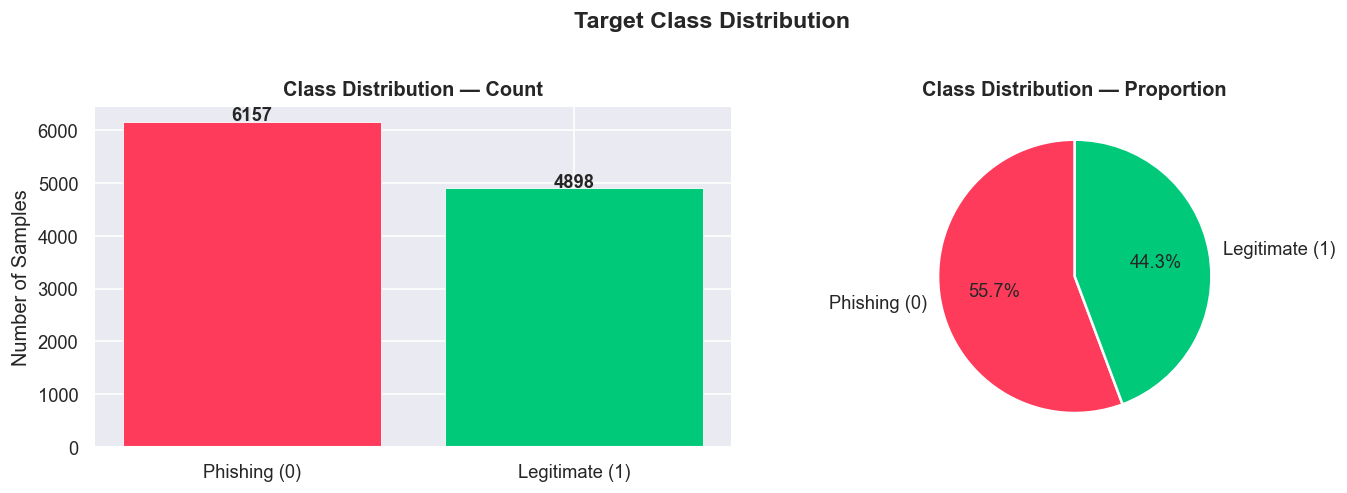


✅ Dataset is well-balanced (ratio: 1.26)


In [7]:
class_counts = df['Result'].value_counts()
class_labels = ['Phishing (0)', 'Legitimate (1)']
class_pct = (class_counts / len(df) * 100).round(2)

print('Class Distribution:')
print(f'  Phishing   (0): {class_counts[0]} samples ({class_pct[0]}%)')
print(f'  Legitimate (1): {class_counts[1]} samples ({class_pct[1]}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#ff3b5c', '#00c97a']
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Distribution — Proportion', fontweight='bold')

plt.suptitle('Target Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Imbalance check
ratio = class_counts.max() / class_counts.min()
if ratio < 1.5:
    print(f'\n✅ Dataset is well-balanced (ratio: {ratio:.2f})')
else:
    print(f'\n⚠️ Class imbalance detected (ratio: {ratio:.2f}) — consider resampling')

## 📊 Step 6 — Feature Value Distribution

All features in this dataset are **categorical** — encoded as:
- `-1` → Suspicious / Malicious
- `0` → Neutral / Uncertain  
- `1` → Legitimate / Safe

In [8]:
features = [col for col in df.columns if col != 'Result']

# Unique values per feature
print('Unique values per feature:')
for f in features:
    print(f'  {f}: {sorted(df[f].unique())}')

Unique values per feature:
  having_IP_Address: [np.int64(-1), np.int64(1)]
  URL_Length: [np.int64(-1), np.int64(0), np.int64(1)]
  Shortining_Service: [np.int64(-1), np.int64(1)]
  having_At_Symbol: [np.int64(-1), np.int64(1)]
  double_slash_redirecting: [np.int64(-1), np.int64(1)]
  Prefix_Suffix: [np.int64(-1), np.int64(1)]
  having_Sub_Domain: [np.int64(-1), np.int64(0), np.int64(1)]
  SSLfinal_State: [np.int64(-1), np.int64(0), np.int64(1)]
  Domain_registeration_length: [np.int64(-1), np.int64(1)]
  Favicon: [np.int64(-1), np.int64(1)]
  port: [np.int64(-1), np.int64(1)]
  HTTPS_token: [np.int64(-1), np.int64(1)]
  Request_URL: [np.int64(-1), np.int64(1)]
  URL_of_Anchor: [np.int64(-1), np.int64(0), np.int64(1)]
  Links_in_tags: [np.int64(-1), np.int64(0), np.int64(1)]
  SFH: [np.int64(-1), np.int64(0), np.int64(1)]
  Submitting_to_email: [np.int64(-1), np.int64(1)]
  Abnormal_URL: [np.int64(-1), np.int64(1)]
  Redirect: [np.int64(0), np.int64(1)]
  on_mouseover: [np.int64(-1), 

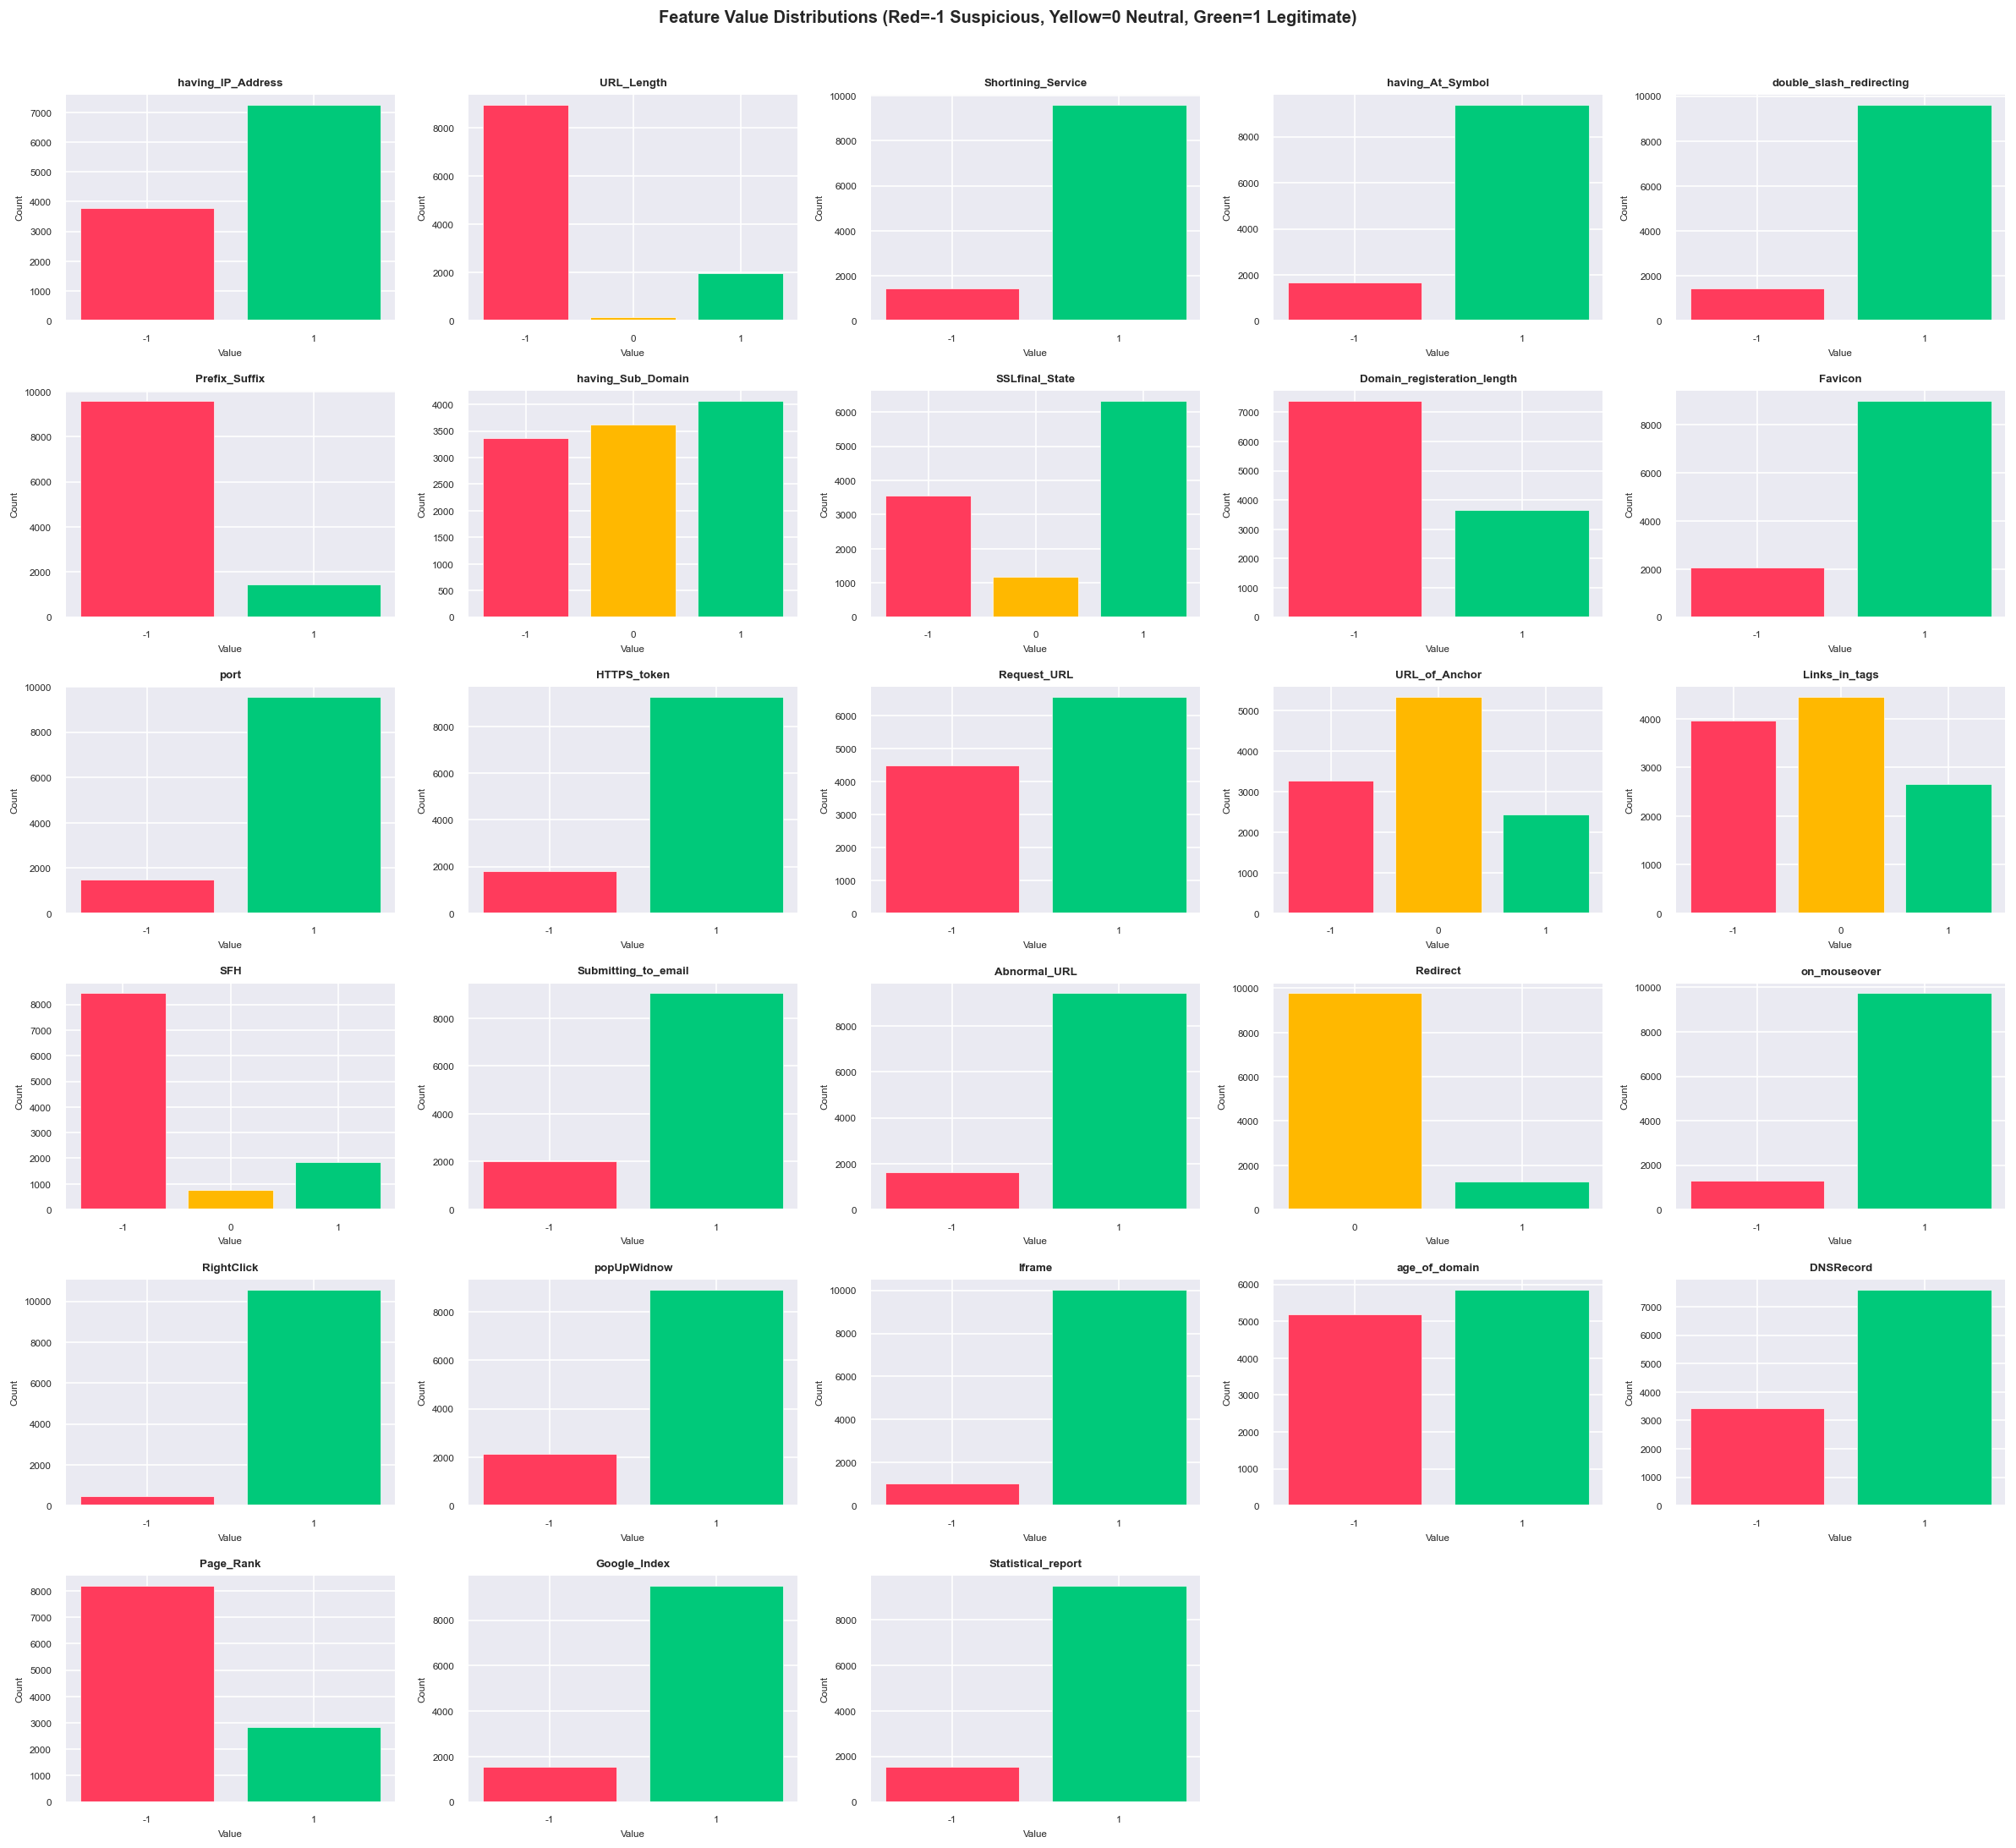

In [9]:
# Grid of bar charts for all 30 features
n_cols = 5
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    counts = df[feat].value_counts().sort_index()
    bar_colors = ['#ff3b5c' if v == -1 else '#ffb800' if v == 0 else '#00c97a' for v in counts.index]
    axes[i].bar(counts.index.astype(str), counts.values, color=bar_colors, edgecolor='white', linewidth=0.4)
    axes[i].set_title(feat, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Count', fontsize=7)
    axes[i].tick_params(labelsize=7)

# Hide unused axes
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Value Distributions (Red=-1 Suspicious, Yellow=0 Neutral, Green=1 Legitimate)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 🔥 Step 7 — Correlation Heatmap

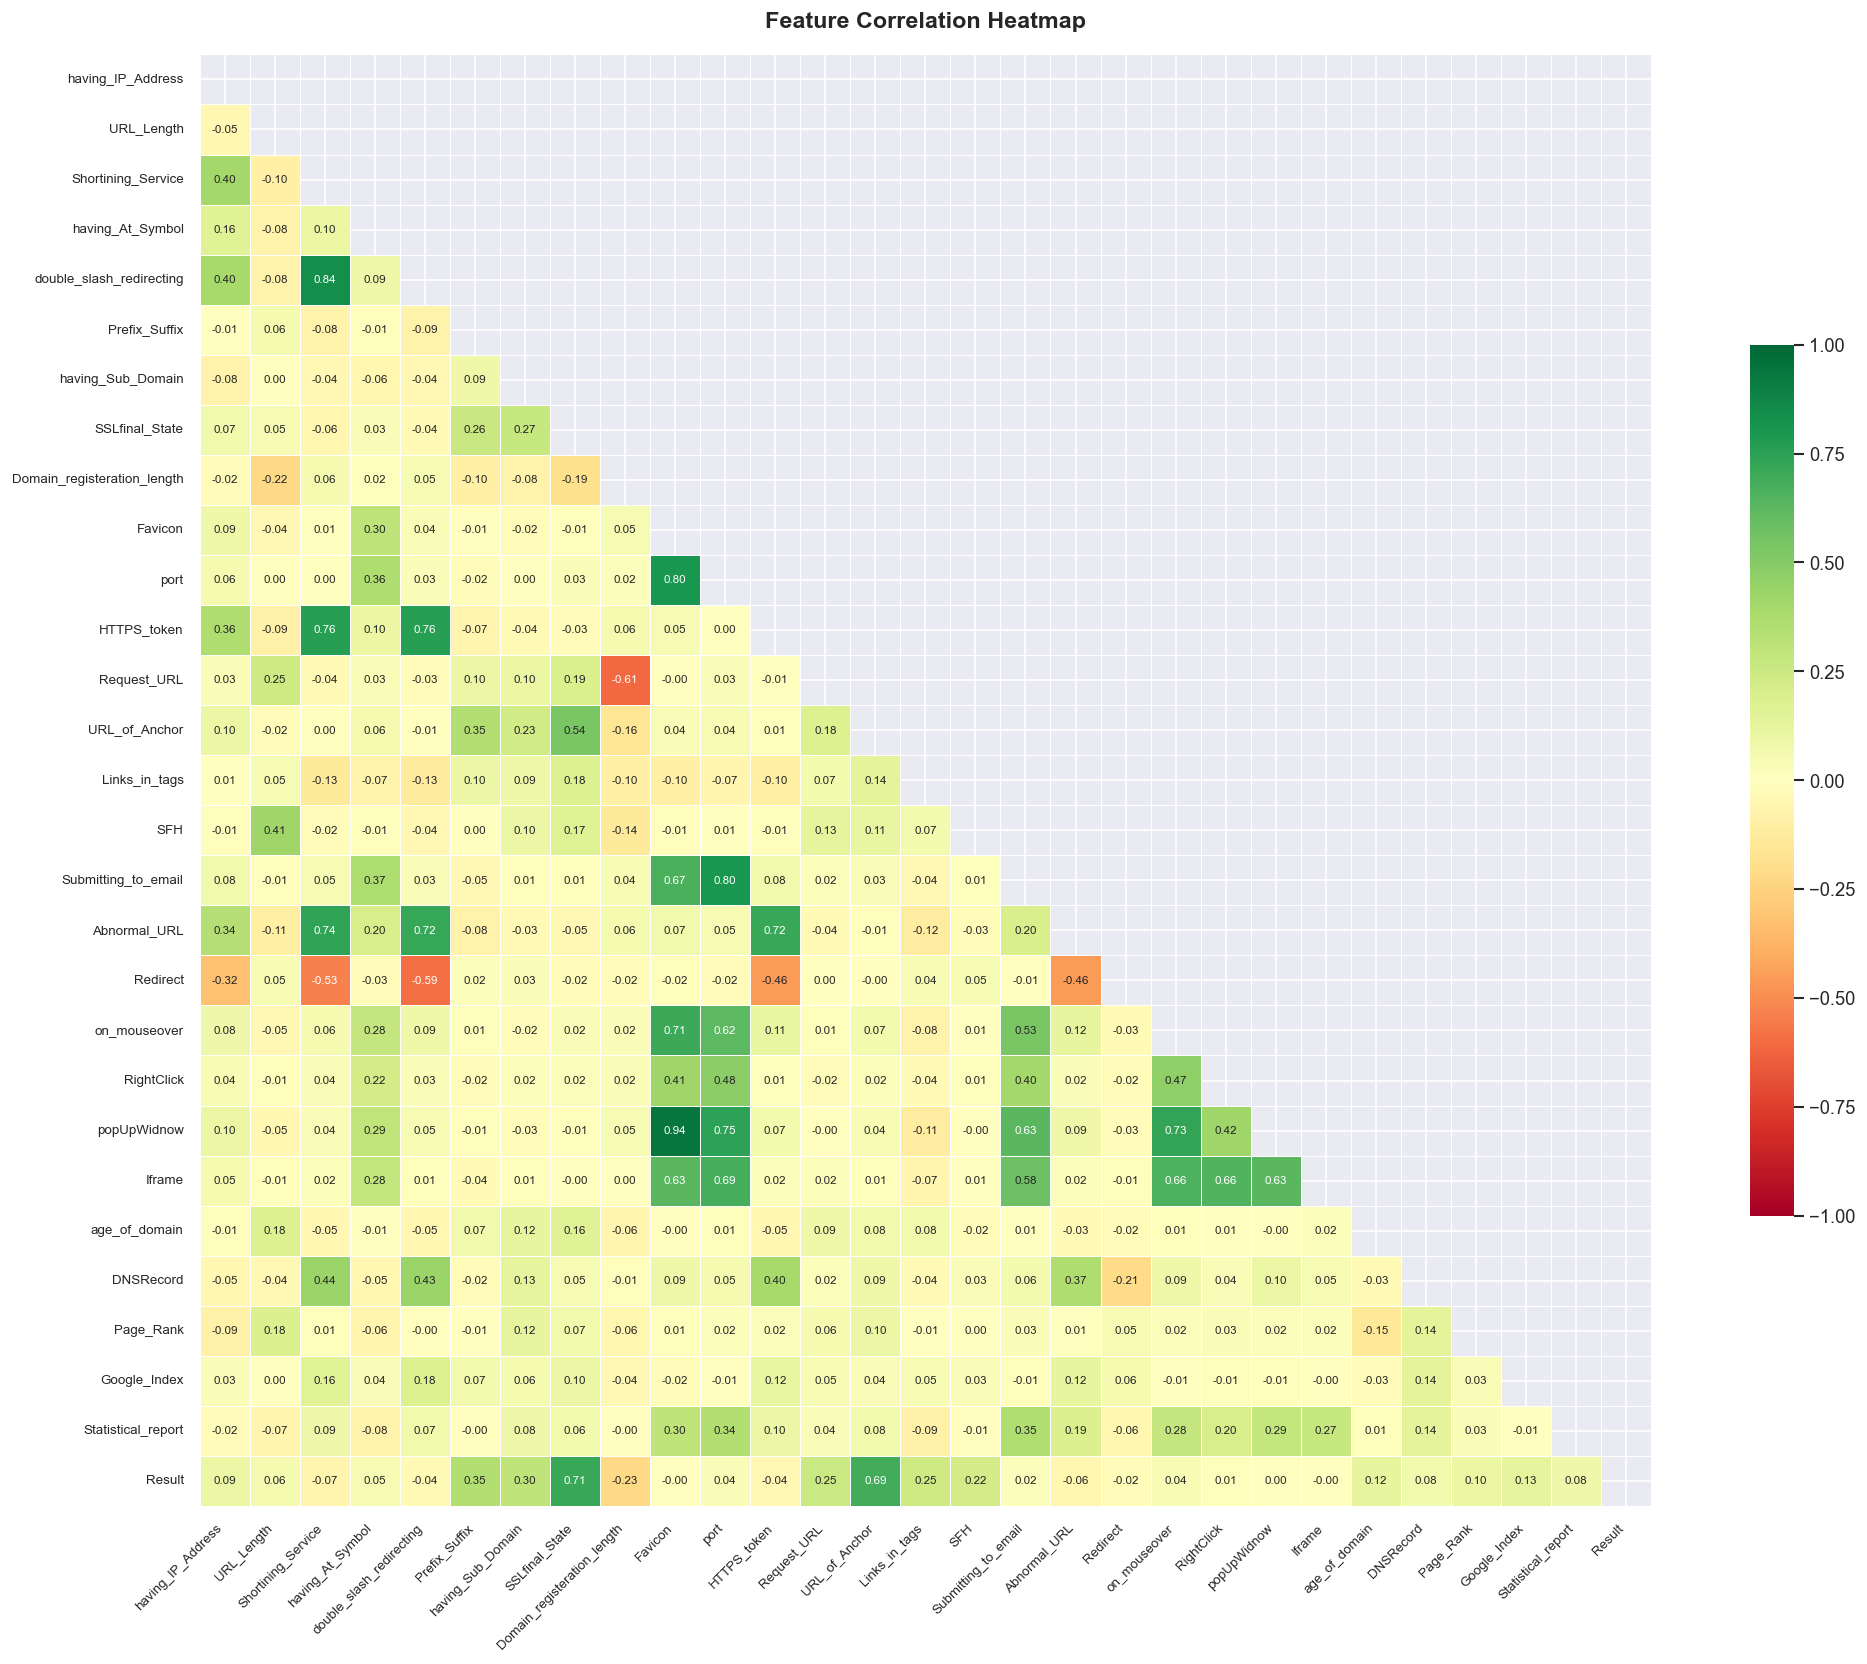

In [10]:
plt.figure(figsize=(18, 14))

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.6}
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 🎯 Step 8 — Feature Correlation with Target (Result)

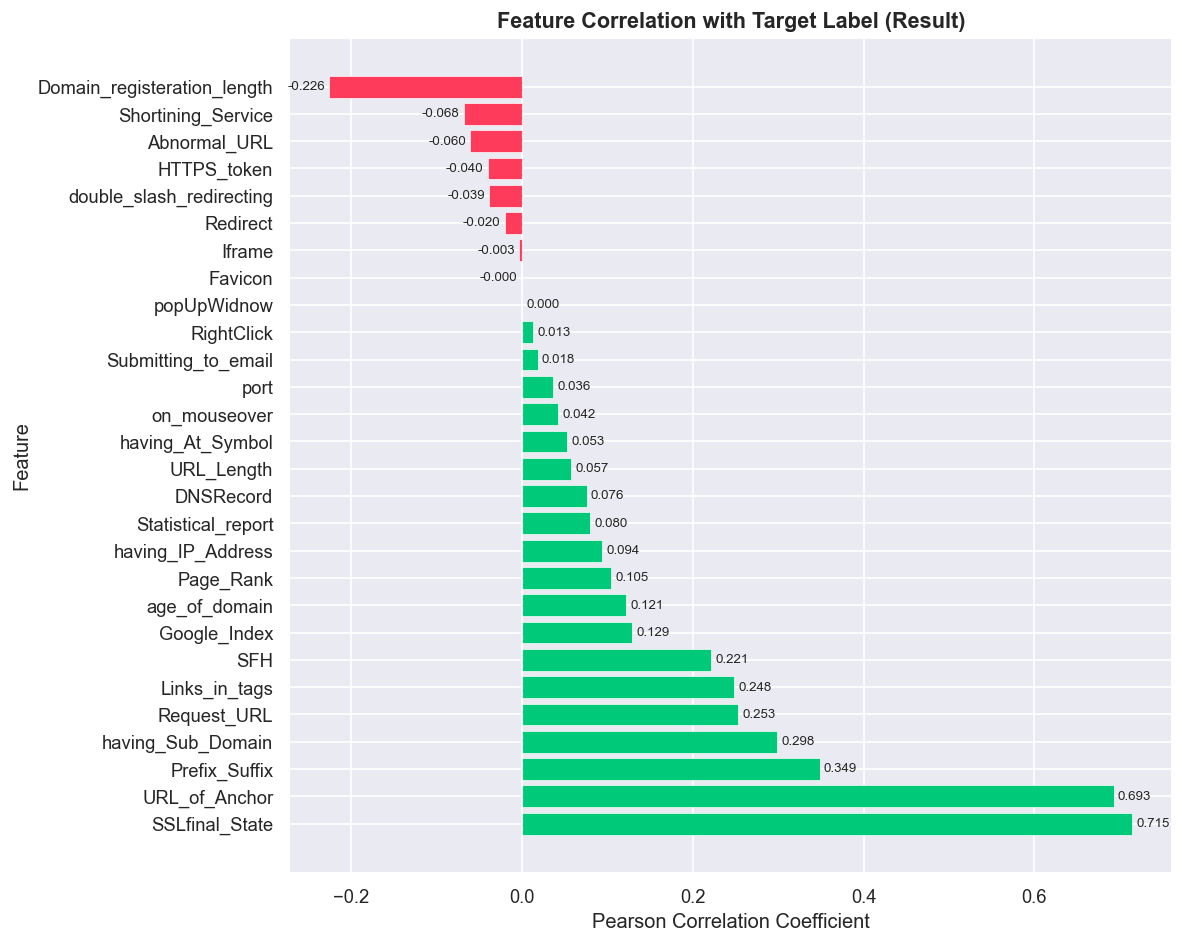

Top 5 features most correlated with phishing:
SSLfinal_State       0.714741
URL_of_Anchor        0.692935
Prefix_Suffix        0.348606
having_Sub_Domain    0.298323
Request_URL          0.253372
Name: Result, dtype: float64


In [11]:
target_corr = df.corr()['Result'].drop('Result').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#00c97a' if v > 0 else '#ff3b5c' for v in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=0.4)
plt.axvline(x=0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Feature Correlation with Target Label (Result)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')

for bar, val in zip(bars, target_corr.values):
    plt.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.show()

print('Top 5 features most correlated with phishing:')
print(target_corr.abs().sort_values(ascending=False).head())

## 📈 Step 9 — Feature Distribution by Class (Phishing vs Legitimate)

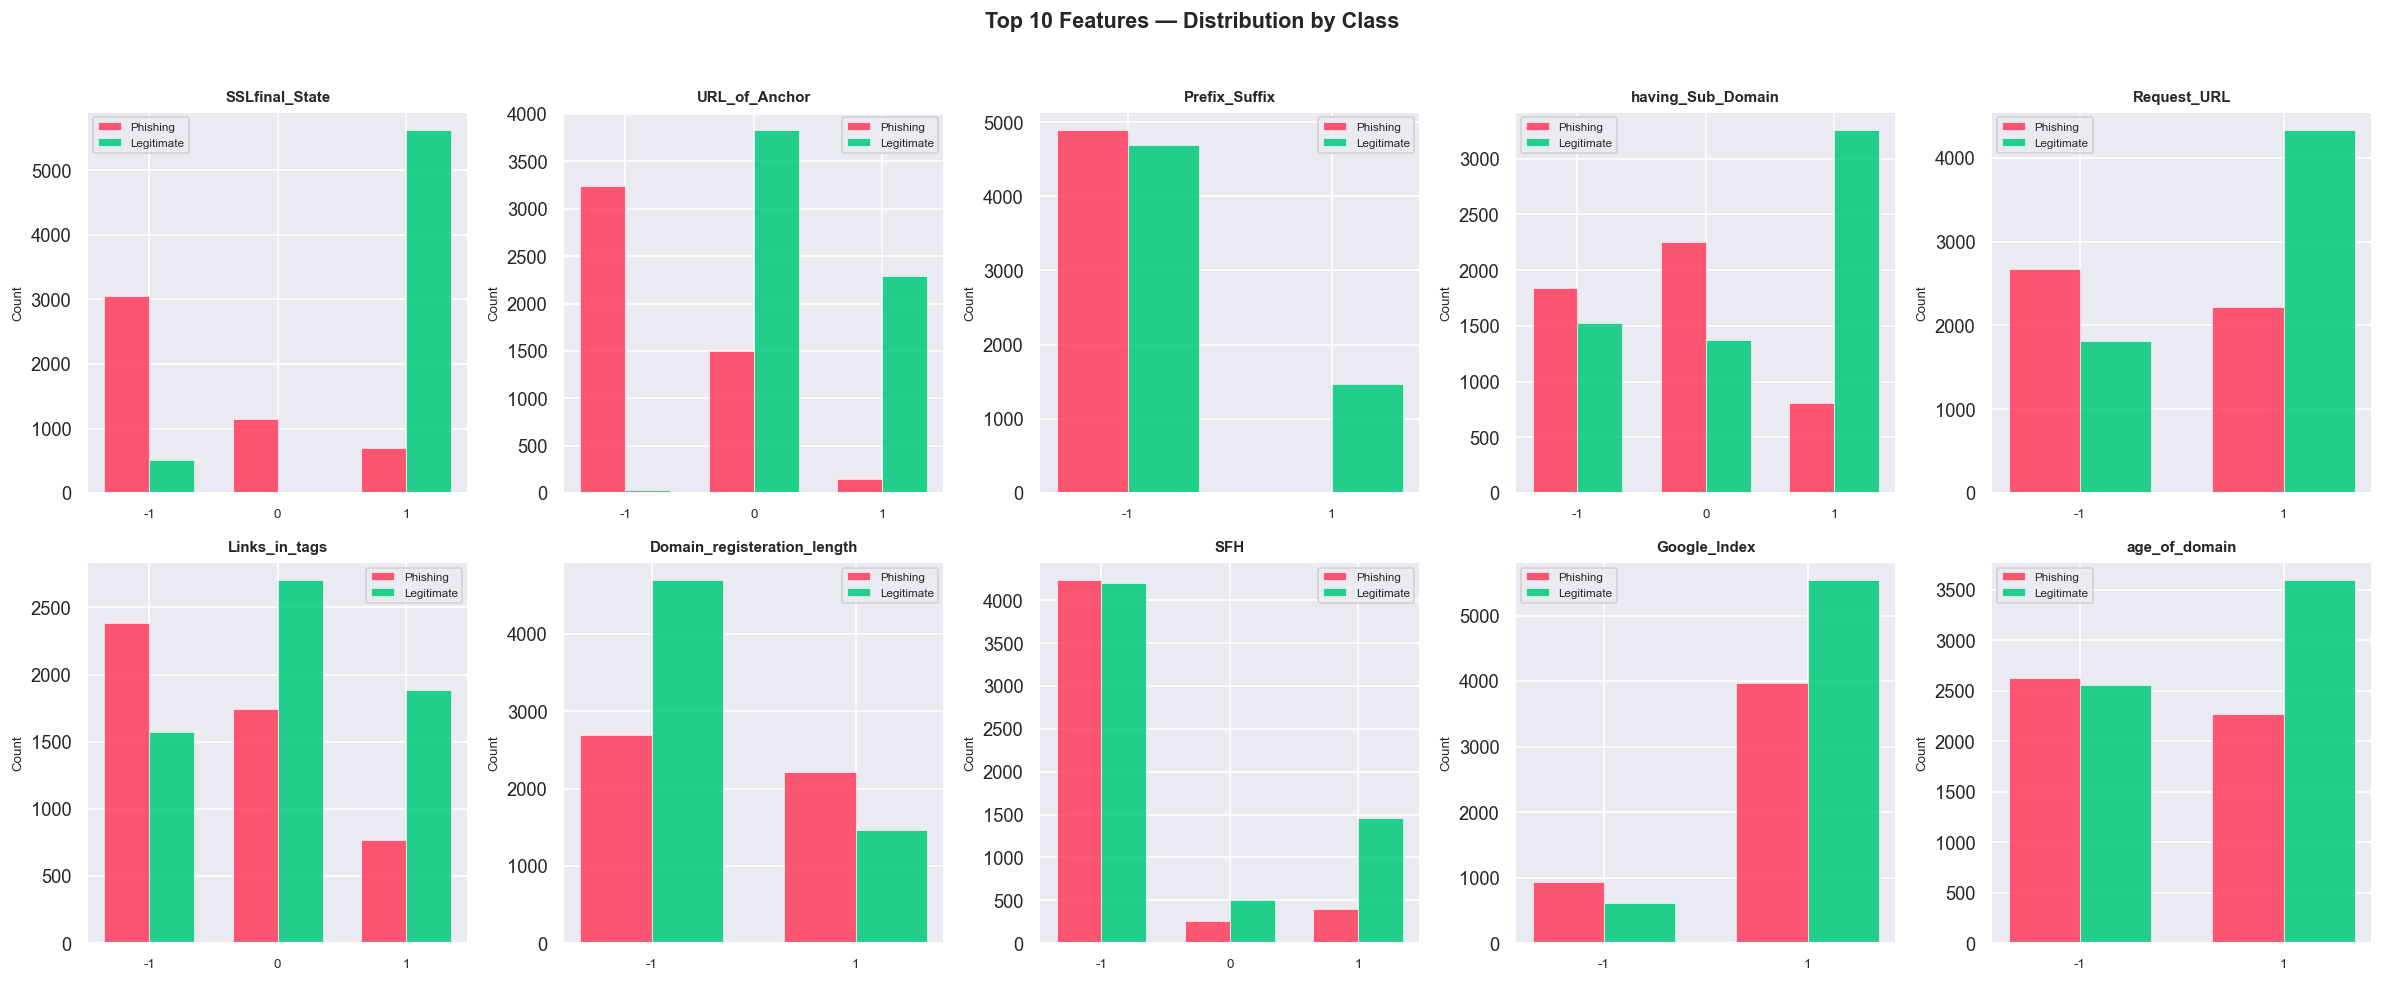

In [12]:
# Top 10 most correlated features
top_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

phishing = df[df['Result'] == 0]
legit = df[df['Result'] == 1]

for i, feat in enumerate(top_features):
    vals = sorted(df[feat].unique())
    x = np.arange(len(vals))
    width = 0.35

    phish_counts = [phishing[feat].value_counts().get(v, 0) for v in vals]
    legit_counts = [legit[feat].value_counts().get(v, 0) for v in vals]

    axes[i].bar(x - width/2, phish_counts, width, label='Phishing', color='#ff3b5c', alpha=0.85, edgecolor='white', linewidth=0.4)
    axes[i].bar(x + width/2, legit_counts, width, label='Legitimate', color='#00c97a', alpha=0.85, edgecolor='white', linewidth=0.4)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(v) for v in vals], fontsize=8)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Top 10 Features — Distribution by Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🌲 Step 10 — Preliminary Feature Importance (using Random Forest)

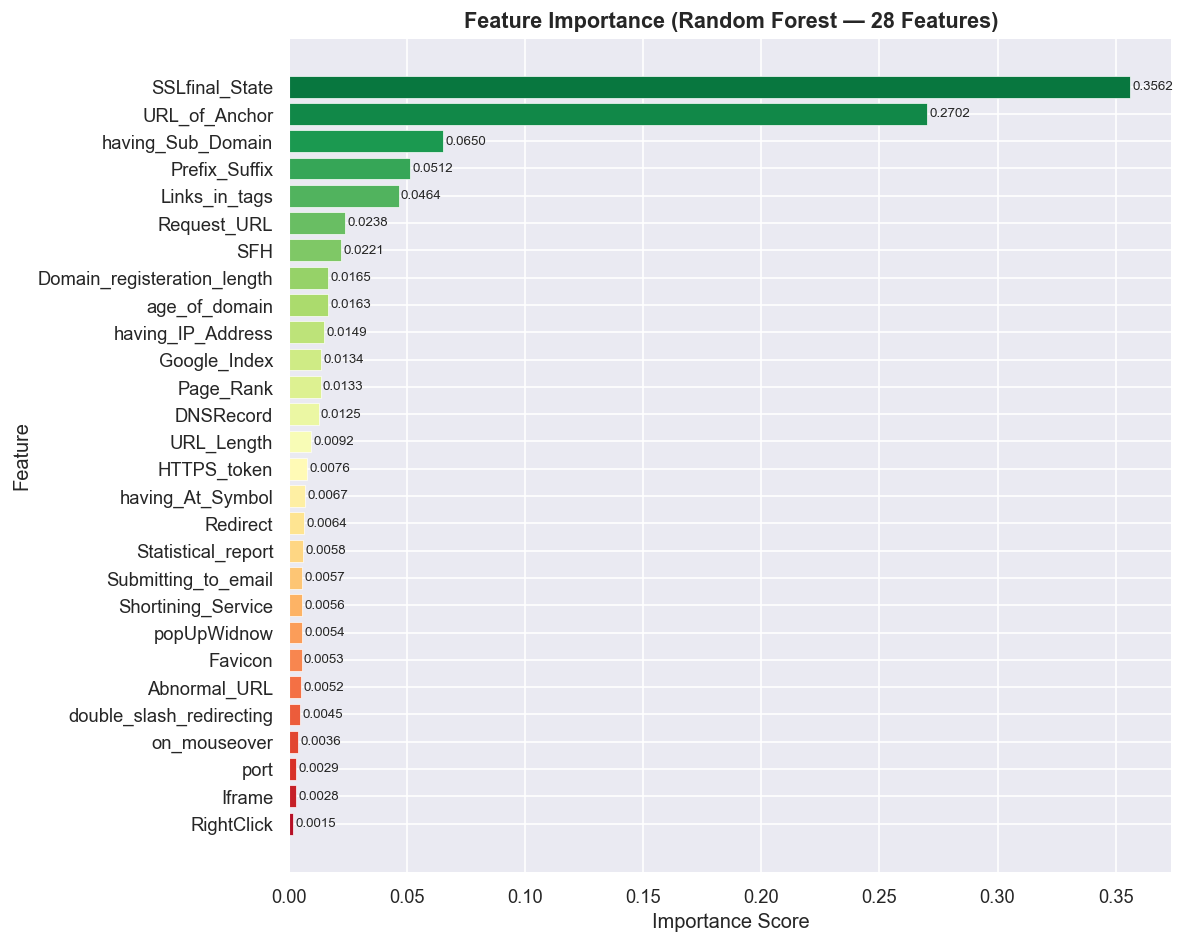

Top 10 most important features:
SSLfinal_State                 0.356248
URL_of_Anchor                  0.270237
having_Sub_Domain              0.065022
Prefix_Suffix                  0.051178
Links_in_tags                  0.046373
Request_URL                    0.023790
SFH                            0.022112
Domain_registeration_length    0.016458
age_of_domain                  0.016349
having_IP_Address              0.014915
dtype: float64


In [13]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Result', axis=1)
y = df['Result']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = sns.color_palette('RdYlGn_r', len(importances))
bars = plt.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.4)
plt.title('Feature Importance (Random Forest — 28 Features)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

for bar, val in zip(bars, importances.values[::-1]):
    plt.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=8
    )

plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(importances.head(10))

## 🔎 Step 11 — Detecting Low Variance Features

Features with variance < 0.01 (candidates for removal):
  None — all features have sufficient variance!


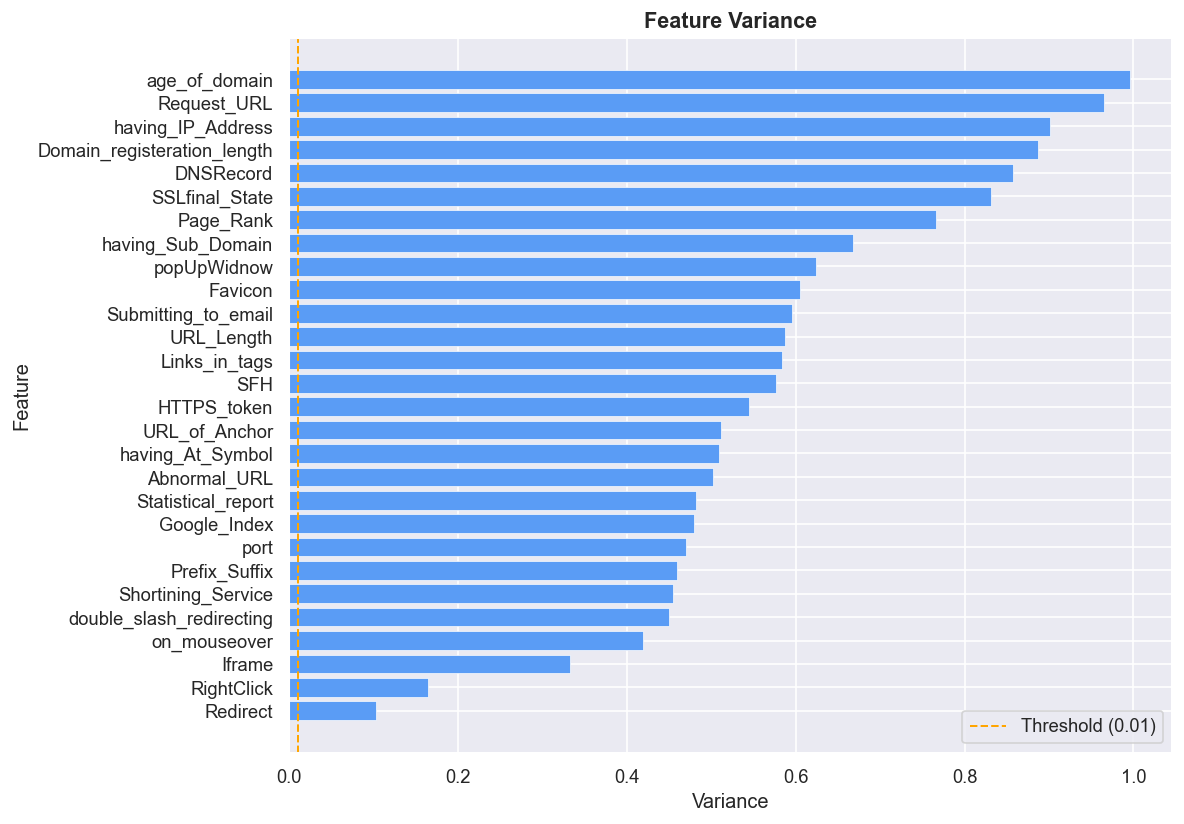

In [14]:
from sklearn.feature_selection import VarianceThreshold

X = df.drop('Result', axis=1)

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

low_var_features = X.columns[~selector.get_support()].tolist()
variances = pd.Series(X.var(), name='Variance').sort_values()

print(f'Features with variance < 0.01 (candidates for removal):')
if low_var_features:
    for f in low_var_features:
        print(f'  {f}: variance = {X[f].var():.5f}')
else:
    print('  None — all features have sufficient variance!')

plt.figure(figsize=(10, 7))
plt.barh(variances.index, variances.values,
         color=['#ff3b5c' if v < 0.01 else '#5a9cf5' for v in variances.values],
         edgecolor='white', linewidth=0.4)
plt.axvline(x=0.01, color='orange', linestyle='--', linewidth=1.2, label='Threshold (0.01)')
plt.title('Feature Variance', fontsize=13, fontweight='bold')
plt.xlabel('Variance')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()

## 📝 Step 12 — EDA Summary & Observations

In [15]:
print('=' * 55)
print('        EDA SUMMARY — PHISHING DETECTION DATASET')
print('=' * 55)
print(f'  Total samples         : {len(df)}')
print(f'  Total features        : {len(features)}')
print(f'  Missing values        : {df.isnull().sum().sum()}')
print(f'  Phishing samples (0)  : {class_counts[0]} ({class_pct[0]}%)')
print(f'  Legitimate samples (1): {class_counts[1]} ({class_pct[1]}%)')
print(f'  Class balance ratio   : {ratio:.2f}')
print(f'  Low variance features : {len(low_var_features) if low_var_features else 0}')
print()
print('  Top 5 predictive features:')
for rank, (feat, score) in enumerate(importances.head(5).items(), 1):
    print(f'    {rank}. {feat} ({score:.4f})')
print('=' * 55)
print('  ✅ Dataset is ready for model training!')
print('=' * 55)

        EDA SUMMARY — PHISHING DETECTION DATASET
  Total samples         : 11055
  Total features        : 28
  Missing values        : 0
  Phishing samples (0)  : 4898 (44.31%)
  Legitimate samples (1): 6157 (55.69%)
  Class balance ratio   : 1.26
  Low variance features : 0

  Top 5 predictive features:
    1. SSLfinal_State (0.3562)
    2. URL_of_Anchor (0.2702)
    3. having_Sub_Domain (0.0650)
    4. Prefix_Suffix (0.0512)
    5. Links_in_tags (0.0464)
  ✅ Dataset is ready for model training!
